# Detección de melanomas — VGG16

**Clasificación binaria de lesiones dermatoscópicas (benigno / maligno) con VGG16**

Adrián Barriuso Pizarro · 2026

---

**Arquitectura** | Detalle
---|---
Backbone | VGG16 (ImageNet) + GAP → Dense(256,ReLU) → Dropout(0.5) → Dense(1,Sigmoid)
Dataset | Melanoma Skin Cancer (10 000 imágenes, Kaggle, CC0)
Split | Train 7 684 / Val 1 921 / Test 1 000 (50/50 balanceado)
Seed | 42
Parámetros totales / entrenables | 14 846 273 / 131 585

**Fase 1** — VGG16 congelado, RMSprop 1e-4, 20 epochs, EarlyStopping patience=7.

**Fase 2** — Últimas 4 capas (block5) descongeladas, Adam 1e-5, 30 epochs.


In [ ]:
!pip install tensorflow --quiet

In [ ]:
import os, random, json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.metrics import (
    classification_report, roc_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay,
)
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

BASE_DIR  = "/content/drive/MyDrive/melanoma_cancer_dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")
CLASS_NAMES = ["benign", "malignant"]

MODEL_DIR  = "/content/drive/MyDrive/melanoma_model"
os.makedirs(MODEL_DIR, exist_ok=True)
print("Dataset en:", BASE_DIR)
print("Modelos en:", MODEL_DIR)

## 1. Pipeline de datos con `tf.data`

El pipeline de entrada se construye con `tf.data` en lugar del clásico
`ImageDataGenerator`. Esta elección evita un problema sutil de los generadores
basados en Python: cuando el número de pasos por época por el tamaño de lote
supera las muestras disponibles, el generador se agota y el entrenamiento avanza
de época en silencio, perdiendo lotes.

`tf.keras.utils.image_dataset_from_directory` combinado con `.prefetch(AUTOTUNE)`
ofrece:

- **Iteración correcta** de todos los lotes, sin agotamiento.
- **Solapamiento CPU/GPU** mediante prefetch asíncrono.
- **Aumento de datos como capas** del grafo: reproducible y eficiente.

In [8]:
# AUTOTUNE deja que tf.data ajuste automáticamente el nivel de paralelismo
# de las operaciones de lectura/preprocesado según los recursos disponibles.
AUTOTUNE = tf.data.AUTOTUNE

# label_mode='binary' devuelve labels como float32 (0.0 o 1.0) en vez de
# enteros, que es lo que espera binary_crossentropy.
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Usamos la misma carpeta + misma seed para que el split sea complementario
# al de training (sin solapamiento de imágenes entre train y val).
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# shuffle=False en test para que las predicciones mantengan el orden
# y se puedan comparar directamente con las etiquetas reales.
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

class_names = train_ds.class_names
print(f"Clases: {class_names}")
print(f"Batches — train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")


Found 9605 files belonging to 2 classes.
Using 7684 files for training.
Found 9605 files belonging to 2 classes.
Using 1921 files for validation.
Found 1000 files belonging to 2 classes.
Clases: ['benign', 'malignant']
Batches — train: 241 | val: 61 | test: 32


In [9]:
# Data augmentation enriquecida con perturbaciones fotometricas.
# Las geometricas (flip/rotation/zoom/translation) ya estaban; anadimos
# brillo y contraste, criticos en dermatoscopia donde la iluminacion
# varia entre dispositivos y centros clinicos.
normalization = layers.Rescaling(1./255)

augmentation = tf.keras.Sequential([
    # Geometricas
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    # Fotometricas: simulan diferencias de iluminacion y captura
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
], name='augmentation')

def preprocess_train(x, y):
    x = normalization(x)
    x = augmentation(x, training=True)
    return x, y

def preprocess_eval(x, y):
    return normalization(x), y

train_ds = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess_eval,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess_eval,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


/tmp/ipykernel_1866/3507089301.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  clase = class_names[int(labels[i].numpy())]


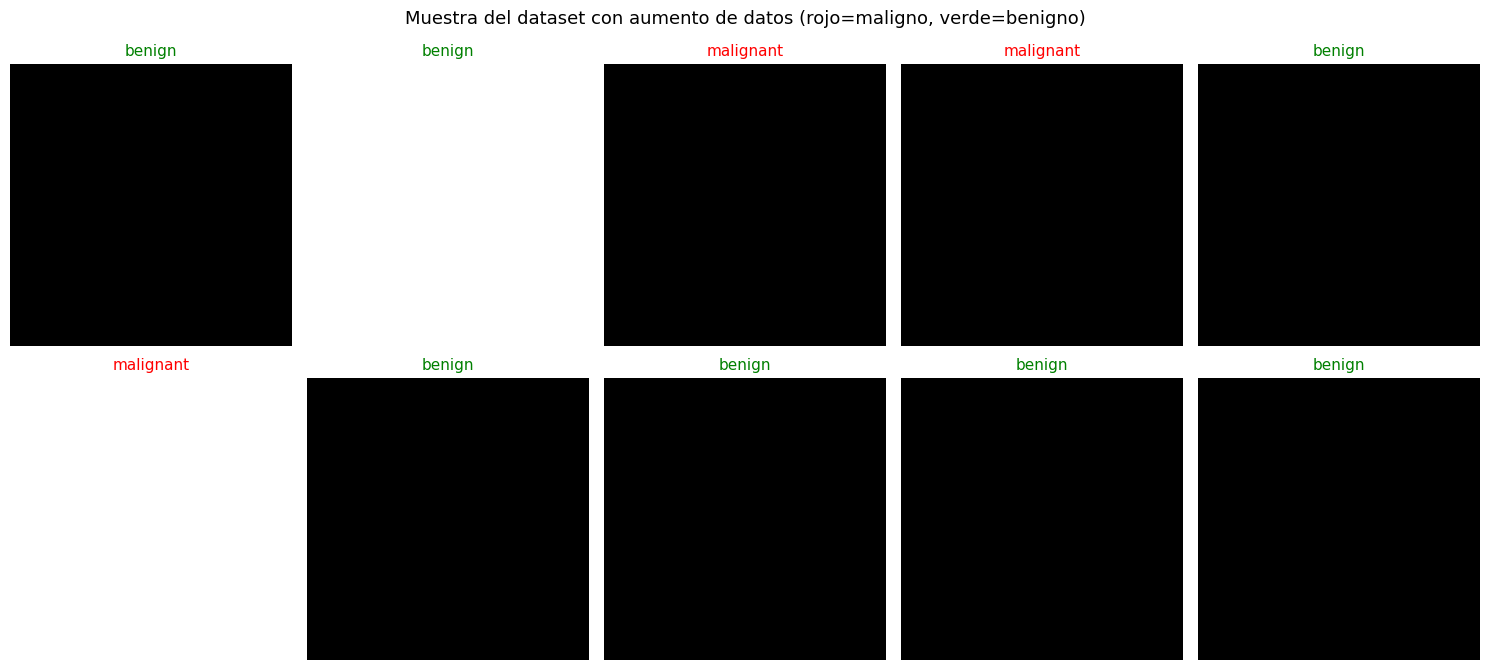

In [10]:
# Visualización de una muestra del dataset con aumento de datos aplicado
imgs, labels = next(iter(train_ds))

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[i].numpy())
    clase = class_names[int(labels[i].numpy())]
    ax.set_title(clase, color='red' if clase == 'malignant' else 'green', fontsize=11)
    ax.axis('off')
plt.suptitle('Muestra del dataset con aumento de datos (rojo=maligno, verde=benigno)', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Arquitectura del modelo

In [ ]:
# include_top=False descarta las capas densas originales de VGG16
base = VGG16(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base.trainable = False  # Fase 1: congelado

inputs = layers.Input(shape=(224, 224, 3))
x = tf.cast(inputs, tf.float32)
# El pipeline ya aplica Rescaling(1/255)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

modelo = Model(inputs, outputs)
modelo.summary()

## 3. Fase 1 — Extracción de características

In [12]:
def crear_callbacks(nombre_modelo, paciencia_es=7, paciencia_lr=3):
    """
    Crea callbacks estándar para el entrenamiento.

    Parámetros:
        nombre_modelo : str  — nombre del archivo .keras a guardar en MODEL_DIR
        paciencia_es  : int  — épocas sin mejora antes de parar (EarlyStopping)
        paciencia_lr  : int  — épocas sin mejora antes de reducir LR (ReduceLROnPlateau)

    Retorna:
        list de callbacks [ModelCheckpoint, EarlyStopping, ReduceLROnPlateau]
    """
    ruta = os.path.join(MODEL_DIR, nombre_modelo)
    return [
        ModelCheckpoint(
            ruta, monitor='val_loss', save_best_only=True, mode='min', verbose=1
        ),
        EarlyStopping(
            monitor='val_loss', patience=paciencia_es,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=paciencia_lr,
            min_lr=1e-7, verbose=1
        ),
    ]

In [ ]:
from tensorflow.keras.optimizers import RMSprop

MODELO_ID = "vgg16"
class_weight = {0: 1.0, 1: 1.3}

callbacks_f1 = crear_callbacks(
    f"melanoma_{MODELO_ID}_phase1.keras",
    paciencia_es=7, paciencia_lr=3
)

modelo.compile(
    optimizer=RMSprop(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history_f1 = modelo.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=callbacks_f1,
    verbose=1,
)
print(f"\nMejor val_loss: {min(history_f1.history['val_loss']):.4f}")

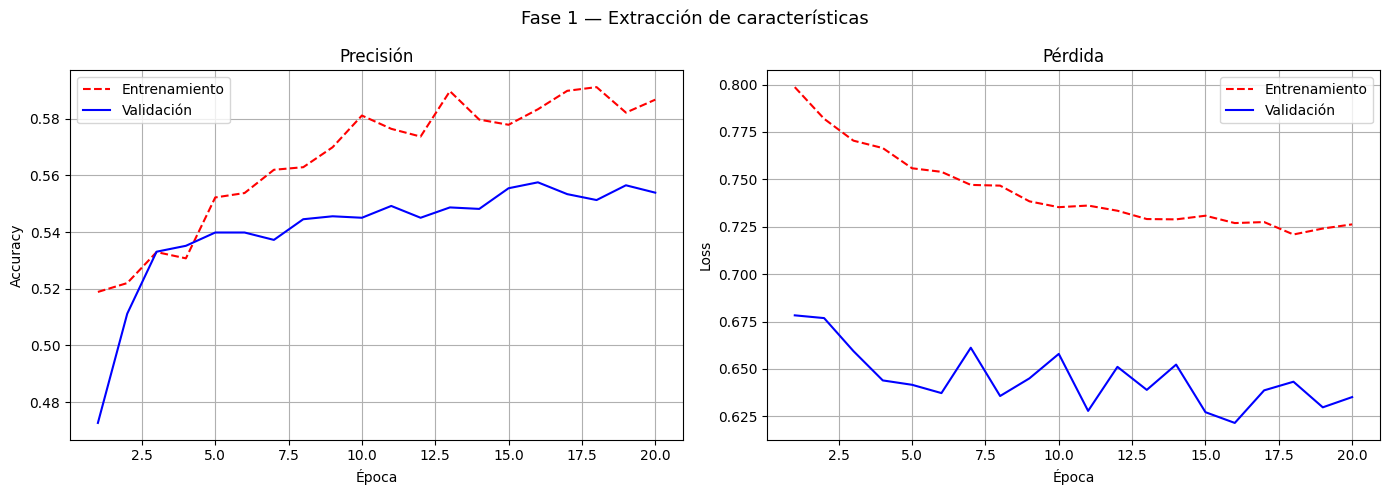

Mejor val_accuracy : 0.5575
Mejor val_loss     : 0.6215


In [14]:
def graficar_historial(history, titulo=''):
    """
    Dibuja accuracy y loss de entrenamiento/validación.

    Compatible con las claves 'accuracy' (Keras 2.x) y 'acc' (Keras 1.x).
    No depende de variables globales: toda la información viene del objeto history.

    Parámetros:
        history : objeto retornado por model.fit()
        titulo  : str opcional para el título del gráfico
    """
    clave    = 'accuracy' if 'accuracy' in history.history else 'acc'
    acc      = history.history[clave]
    val_acc  = history.history[f'val_{clave}']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epocas   = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    if titulo:
        fig.suptitle(titulo, fontsize=13)

    ax1.plot(epocas, acc,     'r--', label='Entrenamiento')
    ax1.plot(epocas, val_acc, 'b',   label='Validación')
    ax1.set_title('Precisión')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epocas, loss,     'r--', label='Entrenamiento')
    ax2.plot(epocas, val_loss, 'b',   label='Validación')
    ax2.set_title('Pérdida')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()
    print(f"Mejor val_accuracy : {max(val_acc):.4f}")
    print(f"Mejor val_loss     : {min(val_loss):.4f}")


graficar_historial(history_f1, 'Fase 1 — Extracción de características')

## 4. Fase 2 — Fine-tuning

Descongelamos las últimas 4 capas de VGG16 (block5_conv1-3, block5_pool).


In [ ]:
# FASE 2: Fine-tuning
base.trainable = True
for layer in base.layers[:-4]:
    layer.trainable = False

print("Capas entrenables:")
for i, layer in enumerate(base.layers):
    if layer.trainable:
        print(f"  {i}: {layer.name}")

In [ ]:
from tensorflow.keras.optimizers import Adam

modelo.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

callbacks_f2 = crear_callbacks(
    f"melanoma_{MODELO_ID}_finetuning.keras",
    paciencia_es=10, paciencia_lr=4
)

history_f2 = modelo.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight,
    callbacks=callbacks_f2,
    verbose=1,
)
print(f"\nMejor val_loss: {min(history_f2.history['val_loss']):.4f}")

In [ ]:
graficar_historial(history_f2, "VGG16 — Fine-tuning")

## 5. Evaluación sobre el conjunto de test

In [ ]:
test_loss, test_acc = modelo.evaluate(test_ds, verbose=1)
print(f"\nTest accuracy : {test_acc:.4f}")
print(f"Test loss     : {test_loss:.4f}")

y_true_all = []; y_pred_all = []; y_prob_all = []
for imgs, labels in test_ds:
    preds = modelo.predict(imgs, verbose=0).flatten()
    y_true_all.extend(labels.numpy())
    y_prob_all.extend(preds)
    y_pred_all.extend((preds >= 0.5).astype(int))

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
y_prob_all = np.array(y_prob_all)

print("\n" + "=" * 60)
print("REPORTE DE CLASIFICACIÓN")
print("=" * 60)
print(classification_report(y_true_all, y_pred_all, target_names=CLASS_NAMES))

fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
roc_auc = auc(fpr, tpr)
print(f"\nAUC: {roc_auc:.4f}")

cm = confusion_matrix(y_true_all, y_pred_all)
tn, fp, fn, tp = cm.ravel()
print(f"\nMatriz de confusión:")
print(f"  TN={tn}  FP={fp}")
print(f"  FN={fn}  TP={tp}")
sens = tp / (tp + fn) if (tp + fn) > 0 else 0
spec = tn / (tn + fp) if (tn + fp) > 0 else 0
print(f"\nSensibilidad (Recall maligno): {sens:.4f}")
print(f"Especificidad:                 {spec:.4f}")

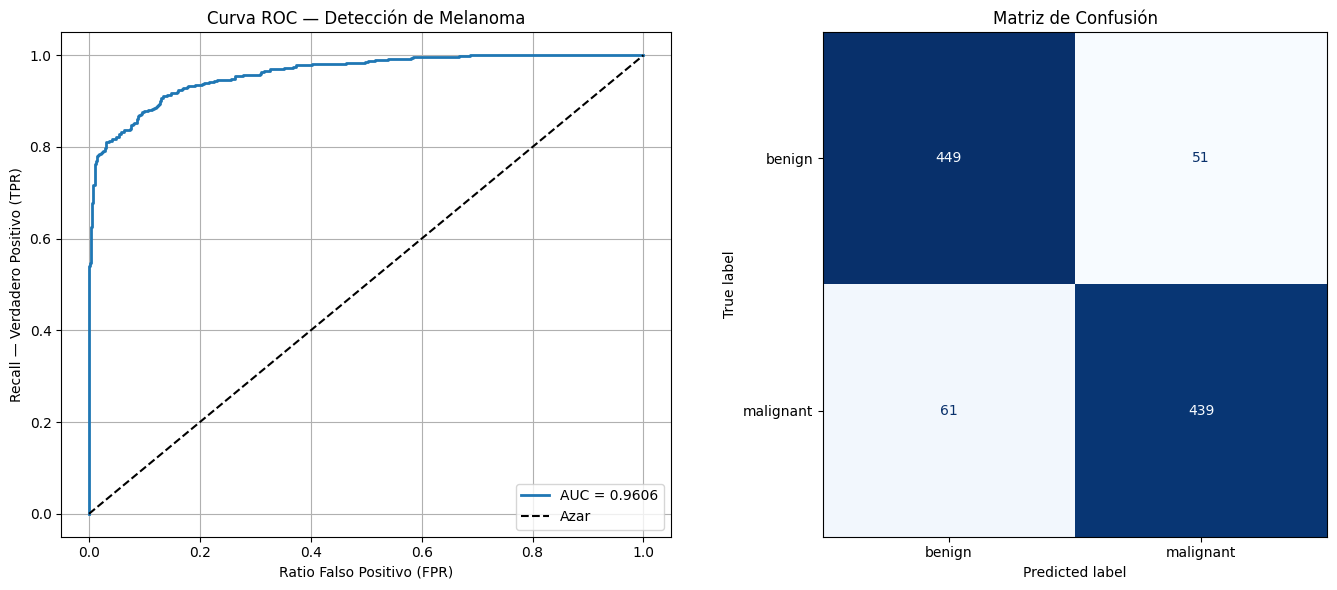


Falsos negativos (maligno→benigno): 61  ← errores clínicamente peligrosos
Falsos positivos (benigno→maligno):  51
Recall malignant                   : 87.80%


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Curva ROC
ax1.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Azar')
ax1.set_xlabel('Ratio Falso Positivo (FPR)')
ax1.set_ylabel('Recall — Verdadero Positivo (TPR)')
ax1.set_title('Curva ROC — Detección de Melanoma')
ax1.legend()
ax1.grid(True)

# Matriz de confusión
cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax2, cmap='Blues', colorbar=False)
ax2.set_title('Matriz de Confusión')

plt.tight_layout()
plt.show()

# Resumen de errores clínicos
fn = cm[1][0]  # malignant predicho como benign
fp = cm[0][1]  # benign predicho como malignant
recall_malignant = cm[1][1] / (cm[1][0] + cm[1][1])
print(f"\nFalsos negativos (maligno→benigno): {fn}  ← errores clínicamente peligrosos")
print(f"Falsos positivos (benigno→maligno):  {fp}")
print(f"Recall malignant                   : {recall_malignant:.2%}")

### 5.1 Calibración (Temperature Scaling)

In [ ]:
from scipy.optimize import minimize_scalar

val_logits = []; val_labels = []
for imgs, labels in val_ds:
    logits = modelo.predict(imgs, verbose=0).flatten()
    logits = np.clip(logits, 1e-7, 1 - 1e-7)
    logits = np.log(logits / (1 - logits))
    val_logits.extend(logits)
    val_labels.extend(labels.numpy())
val_logits = np.array(val_logits)
val_labels = np.array(val_labels)

def nll(t):
    cal = 1 / (1 + np.exp(-val_logits / t))
    return -np.mean(val_labels * np.log(cal + 1e-7) + (1 - val_labels) * np.log(1 - cal + 1e-7))

res = minimize_scalar(nll, bounds=(0.05, 10), method="bounded")
T_opt = res.x
print(f"Temperatura óptima: {T_opt:.4f}")
print(f"Copia en constants.js -> temperature: {T_opt:.3f}")

## 6. Guardar modelo y convertir a TF.js

In [ ]:
ruta_keras = os.path.join(MODEL_DIR, MODELO_ID, f"melanoma_{MODELO_ID}_final.keras")
os.makedirs(os.path.dirname(ruta_keras), exist_ok=True)
modelo.save(ruta_keras)
print(f"Keras model saved: {ruta_keras}")

In [ ]:
# --- Conversion a TF.js con uint8 quantization ---
!pip install tensorflowjs --quiet
import tensorflowjs as tfjs

# TEMPERATURE = T_opt  # descomenta si ya ejecutaste la celda de calibracion
TEMPERATURE = 1.0

model = tf.keras.models.load_model(ruta_keras)
model.summary()

converted_dir = os.path.join(MODEL_DIR, MODELO_ID, "tfjs")
os.makedirs(converted_dir, exist_ok=True)

tfjs.converters.save_keras_model(
    model,
    converted_dir,
    quantization_dtype={"uint8": "*"},
    metadata={
        "temperature": TEMPERATURE,
        "version": "1.0.0",
        "modelId": MODELO_ID,
        "convertedAt": str(datetime.now()),
    },
)
print(f"TF.js model saved to: {converted_dir}")
for f in sorted(os.listdir(converted_dir)):
    print(f"  {f}")

---
## Conversión completada

Copia el modelo TF.js al repositorio:

```bash
cp -r "models/${MODELO_ID}/tfjs/*" ../demo/public/model/${MODELO_ID}/
```

Actualiza `temperature` en `demo/src/lib/constants.js`.